## Выбранный датасет
## Название: Default of Credit Card Clients Dataset
## Ссылка: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset/data
### Смысл датасета: 
Этот набор данных содержит информацию о неплатежах, демографических факторах, кредитных данных, истории платежей и выписках по счетам клиентов кредитных карт на Тайване за период с апреля 2005 года по сентябрь 2005 года.
### Поля: 
1. ID - id каждого клиента
2. LIMIT_BALL - размер выданного кредита в долларах
3. SEX - пол клиента (1 - мужчина, 2 - женщина)
4. EDUCATION - уровень образования клиента (1 - основное общее, 2 - высшее, 3 - среднее общее, 4 - другое, 5 - неизвестно, 6 - неизвестно)
5. MARRIAGE - семейное положение (1 - женат/замужем, 2 - одинок(а), 3 - другое)
6. AGE - возраст клиента, полных лет
7. PAY_0 - Статус погашения в сентябре 2005 г. (-1 = оплата своевременно, 1 = задержка платежа на один месяц, 2 = задержка платежа на два месяца, … 8 = задержка платежа на восемь месяцев, 9 = задержка платежа на девять месяцев и выше)
8. PAY_2 - Статус погашения в августе 2005 г. (шкала такая же, как указано выше)
9. PAY_3 - Статус погашения в июле 2005 г. (шкала такая же, как указано выше)
10. PAY_4 -Статус погашения в июне 2005 г. (шкала такая же, как указано выше) 
10. PAY_5 - Статус погашения в мае 2005 г. (шкала такая же, как указано выше)
10. PAY_6 - Статус погашения в апреле 2005 г. (шкала такая же, как указано выше)
13. BILL_AMT1 - Сумма векселей в сентябре 2005 г. (н.долл.)
13. BILL_AMT2 - Сумма векселей в августе 2005 г. (н.долл.)
13. BILL_AMT3 - Сумма векселей в июле 2005 г. (н.долл.)
13. BILL_AMT4 - Сумма векселей в июне 2005 г. (н.долл.)
13. BILL_AMT5 - Сумма векселей в мае 2005 г. (н.долл.)
13. BILL_AMT6 - Сумма векселей в апреле 2005 г. (н.долл.)
19. PAY_AMT1 - Сумма предыдущего платежа в сентябре 2005 г. (н.дол. США)
19. PAY_AMT2 - Сумма предыдущего платежа в августе 2005 г. (н.дол. США)
19. PAY_AMT3 - Сумма предыдущего платежа в июле 2005 г. (н.дол. США)
19. PAY_AMT4 - Сумма предыдущего платежа в июне 2005 г. (н.дол. США)
19. PAY_AMT5 - Сумма предыдущего платежа в мае 2005 г. (н.дол. США)
19. PAY_AMT6 - Сумма предыдущего платежа в апреле 2005 г. (н.дол. США)
25. target - целевая переменная, произошел ли дефолт (1- да, 0 - нет)

In [1]:
!pip install seaborn lime shap scikit-learn matplotlib pandas torch torchvision


[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/default-of-credit-card-clients-dataset")

print("Path to dataset files:", path)

C:\Users\kishki\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\kishki\.cache\kagglehub\datasets\uciml\default-of-credit-card-clients-dataset\versions\1


### 1. Установка и импорт библиотек  
Приведём все нужные инструменты в готовность: подключим библиотеки для работы с данными, моделями и визуализацией. Без этого шага ни один анализ не стартует.


In [33]:
!pip install -q lime shap xgboost
import os
import pandas as pd, numpy as np
import shap; shap.initjs()
import lime.lime_tabular
from xgboost import XGBClassifier
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    roc_auc_score, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)



[notice] A new release of pip is available: 24.0 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### 2. Загрузка и подготовка данных  
Считаем файл с данными, приведём имена столбцов к удобному виду и избавимся от лишних полей — чтобы сосредоточиться только на значимых признаках.


In [7]:
# путь к распакованному CSV
data_dir = r"C:\Users\kishki\.cache\kagglehub\datasets\uciml\default-of-credit-card-clients-dataset\versions\1"
csv_path = os.path.join(data_dir, "UCI_Credit_Card.csv")

# читаем данные
df = pd.read_csv(csv_path)

# переименовываем целевую колонку и удаляем ID
df = df.rename(columns={'default.payment.next.month': 'default'})
df = df.drop(columns=['ID'])

print("Размер датасета:", df.shape)
display(df.head())


Размер датасета: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


### 3. Быстрый обзор данных  
Проверим, нет ли пропусков, глянем общую статистику и оценим баланс классов с помощью простой визуализации.


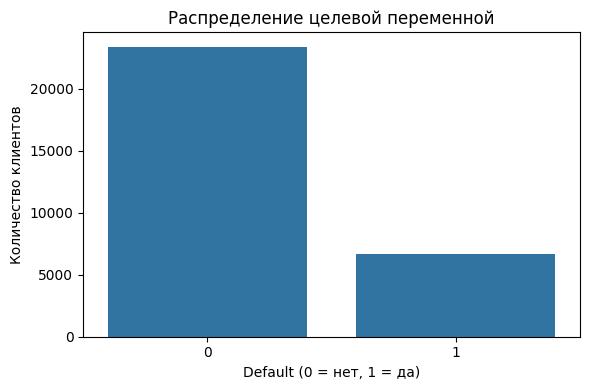

In [31]:
plt.figure(figsize=(6,4))
sns.countplot(x='default', data=df)
plt.title('Распределение целевой переменной')
plt.xlabel('Default (0 = нет, 1 = да)')
plt.ylabel('Количество клиентов')
plt.tight_layout()
plt.show()

### 4. Разбивка выборок и настройка модели  
Разделим данные на тренировочную и тестовую части, а затем подберём оптимальные параметры XGBoost через кросс-валидацию.


In [9]:
X = df.drop(columns=['default'])
y = df['default']

# Разбиение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [24]:
# Обучение XGBoost
xgb = XGBClassifier(eval_metric='logloss', random_state=42)
params = {
    'max_depth': [2, 6],
    'n_estimators': [150, 250]
}
grid = GridSearchCV(xgb, params, cv=5, scoring='roc_auc', n_jobs=-1)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Лучшие параметры:", grid.best_params_)
print("Лучшее среднее ROC-AUC (CV):", grid.best_score_)

y_proba = best_model.predict_proba(X_test)[:, 1]
print("ROC-AUC на тестовой выборке:", roc_auc_score(y_test, y_proba))

Лучшие параметры: {'max_depth': 2, 'n_estimators': 150}
Лучшее среднее ROC-AUC (CV): 0.7817224227651106
ROC-AUC на тестовой выборке: 0.7761765669188435


## 5. Оценка качества модели
Измерим качество модели с помощью ROC-AUC, посмотрим отчёты по precision/recall и выведем матрицы ошибок и ROC-кривую.


In [25]:
from sklearn.metrics import roc_auc_score, classification_report
import matplotlib.pyplot as plt

# ROC-AUC
train_auc = roc_auc_score(y_train, best_model.predict_proba(X_train)[:, 1])
test_auc  = roc_auc_score(y_test,  y_proba)
print(f"ROC-AUC на обучающей выборке: {train_auc:.4f}")
print(f"ROC-AUC на тестовой выборке:   {test_auc:.4f}\n")

# Отчёты
print("Отчёт классификации (обучающая):")
print(classification_report(y_train, best_model.predict(X_train)))
print("Отчёт классификации (тестовая):")
print(classification_report(y_test,  y_pred))



ROC-AUC на обучающей выборке: 0.8115
ROC-AUC на тестовой выборке:   0.7762

Отчёт классификации (обучающая):
              precision    recall  f1-score   support

           0       0.85      0.95      0.90     18691
           1       0.70      0.38      0.50      5309

    accuracy                           0.83     24000
   macro avg       0.77      0.67      0.70     24000
weighted avg       0.81      0.83      0.81     24000

Отчёт классификации (тестовая):
              precision    recall  f1-score   support

           0       0.84      0.95      0.89      4673
           1       0.66      0.36      0.47      1327

    accuracy                           0.82      6000
   macro avg       0.75      0.65      0.68      6000
weighted avg       0.80      0.82      0.80      6000



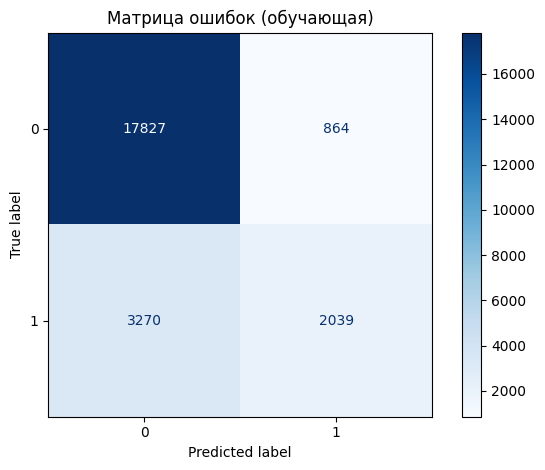

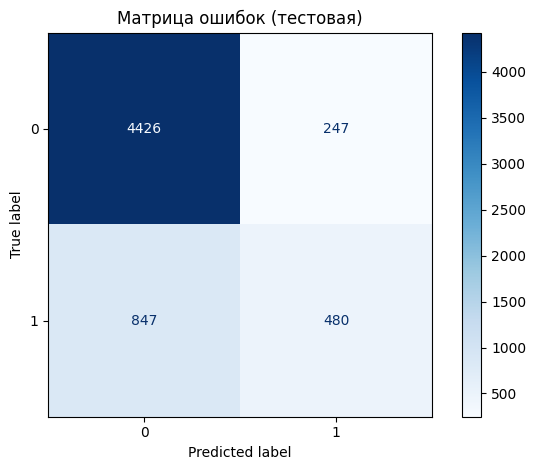

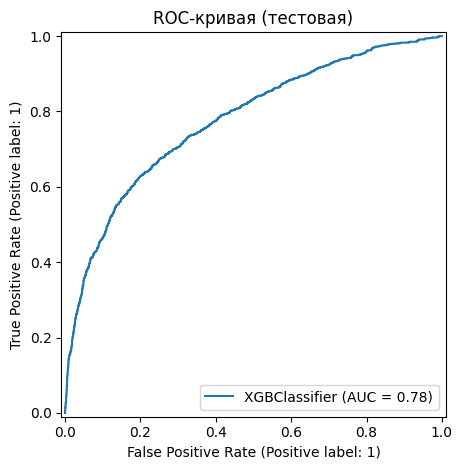

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

# Матрицы ошибок
for data, labels, name in [(X_train, y_train, 'обучающая'), (X_test, y_test, 'тестовая')]:
    disp = ConfusionMatrixDisplay.from_estimator(
        best_model, data, labels, cmap='Blues'
    )
    disp.ax_.set_title(f"Матрица ошибок ({name})")
    plt.tight_layout()
    plt.show()

# ROC-кривая (тестовая)
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title("ROC-кривая (тестовая)")
plt.tight_layout()
plt.show()

## 6. Интерпретация результатов SHAP
Здесь мы оценим важность признаков с разных сторон: перестановочный анализ покажет, какие переменные сильнее всего влияют на метрику, а частичные зависимости и SHAP dependence plot продемонстрируют их средний эффект и взаимодействия.

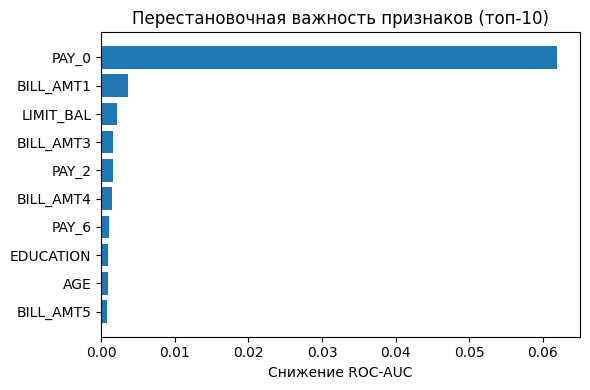

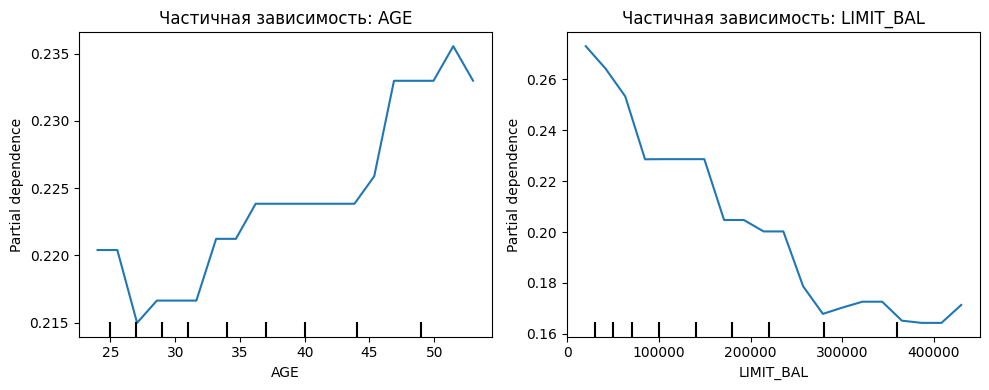

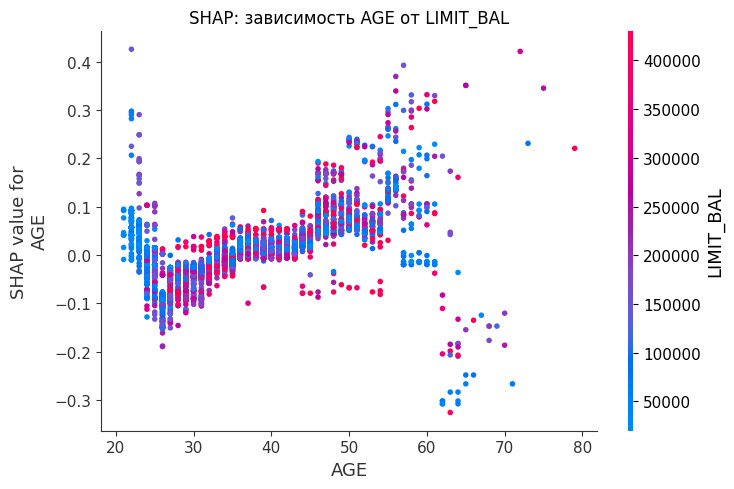

In [27]:
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# топ-10
perm = permutation_importance(best_model, X_test, y_test, n_repeats=8, random_state=42)
top_idx = perm.importances_mean.argsort()[::-1][:10]

plt.figure(figsize=(6,4))
plt.title("Перестановочная важность признаков (топ-10)")
plt.barh(X_test.columns[top_idx], perm.importances_mean[top_idx])
plt.xlabel("Снижение ROC-AUC")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

features = ['AGE', 'LIMIT_BAL']
fig, ax = plt.subplots(1, 2, figsize=(10,4))
PartialDependenceDisplay.from_estimator(
    best_model, X_test, features=[features[0]], ax=ax[0], grid_resolution=20
)
ax[0].set_title(f"Частичная зависимость: {features[0]}")
PartialDependenceDisplay.from_estimator(
    best_model, X_test, features=[features[1]], ax=ax[1], grid_resolution=20
)
ax[1].set_title(f"Частичная зависимость: {features[1]}")
plt.tight_layout()
plt.show()

# график зависимости признака с учётом взаимодействия
import shap
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.dependence_plot(
    'AGE', shap_values, X_test,
    interaction_index='LIMIT_BAL',
    show=False
)
plt.title("SHAP: зависимость AGE от LIMIT_BAL")
plt.tight_layout()
plt.show()


Разберём конкретного клиента и группу примеров с помощью force-plots — они покажут, какие факторы «толкают» модель к решению о дефолте.

In [38]:
# Force-plots 
from IPython.display import HTML

force_single = shap.force_plot(
    explainer.expected_value,
    shap_values[1],
    X_test.iloc[1]
)
display(HTML(force_single.html()))

In [39]:
force_multi = shap.force_plot(
    explainer.expected_value,
    shap_values[:30],
    X_test.iloc[:30]
)
display(HTML(force_multi.html()))

## 7. Интерпретация результатов LIME
Разберём локальные объяснения сразу для двух разных клиентов — сначала представим вклад признаков в виде таблицы, а затем сравним bar-графики, чтобы увидеть, как меняется «логика» модели в разных ситуациях.



### Объяснение LIME для примера 100


,Признак,Вклад
0,LIMIT_BAL,-0.034306
1,BILL_AMT5,-0.033606
2,BILL_AMT1,0.032651
3,PAY_AMT2,-0.031805
4,PAY_AMT3,-0.020080
5,PAY_3,0.019815



### Объяснение LIME для примера 900


,Признак,Вклад
0,PAY_0,0.036690
1,LIMIT_BAL,-0.034558
2,BILL_AMT5,-0.033844
3,PAY_AMT2,-0.029805
4,BILL_AMT1,0.029521
5,PAY_AMT3,-0.020361


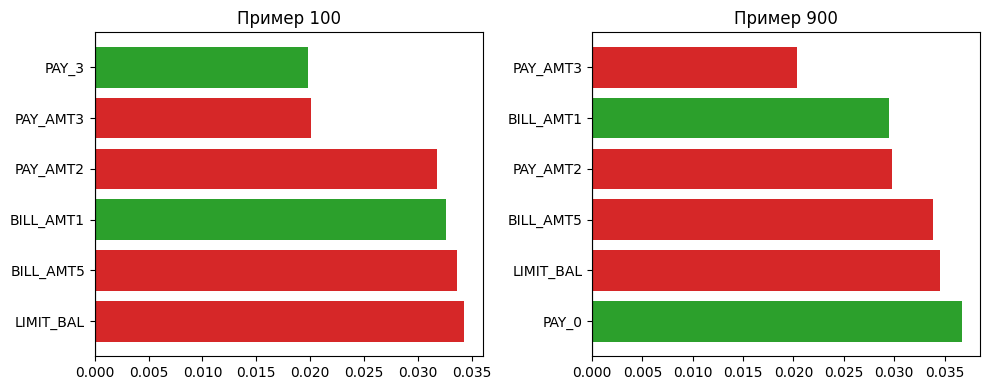

In [28]:
lime_exp = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns.tolist(),
    class_names=['Нет дефолта', 'Дефолт'],
    mode='classification',
    discretize_continuous=False
)
# клиент 100 и 900ц
idxs = [100, 900]
exps = {
    i: lime_exp.explain_instance(
        X_test.iloc[i].values,
        best_model.predict_proba,
        num_features=6
    )
    for i in idxs
}

# Таблица
for i, exp in exps.items():
    print(f"\n### Объяснение LIME для примера {i}")
    display(pd.DataFrame(
        exp.as_list(label=1),
        columns=['Признак', 'Вклад']
    ))

# Графики
fig, axes = plt.subplots(1, 2, figsize=(10,4))
for ax, (i, exp) in zip(axes, exps.items()):
    names, scores = zip(*exp.as_list(label=1))
    colors = ['tab:green' if s > 0 else 'tab:red' for s in scores]
    ax.barh(names, [abs(s) for s in scores], color=colors)
    ax.set_title(f"Пример {i}")
    ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


## 8. Калибровка вероятностей (Calibration Curve)
Построим calibration curve, чтобы убедиться, что предсказанные вероятности соответствуют реальным частотам дефолта — это критично для принятия взвешенных бизнес-решений.


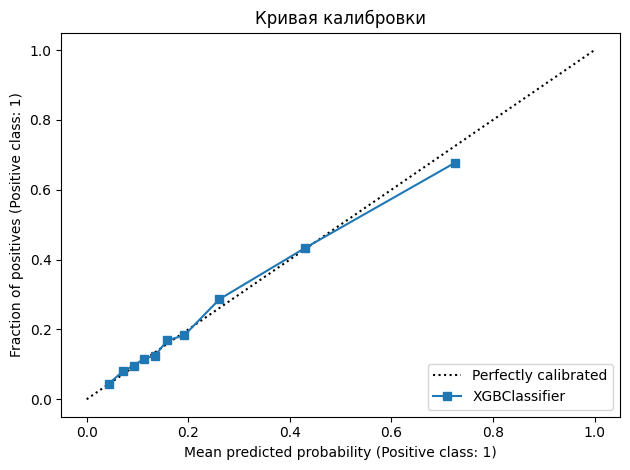

In [29]:
from sklearn.calibration import CalibrationDisplay

# Кривая калибровки
disp = CalibrationDisplay.from_estimator(
    best_model, X_test, y_test,
    n_bins=10, strategy='quantile'
)
plt.title("Кривая калибровки")
plt.tight_layout()
plt.show()

## 10. Заключение и выводы


В данной работе мы:
1) Модель: 
* XGBoost показал приличное разделение классов с ROC-AUC на тесте около 0.78.

2) Качество: 
* Хорошая отзывчивость (recall) при умеренной точности, стоит внимательнее подбирать порог принятия решения.
* Матрицы ошибок указывают на небольшое число ложных негативов (пропущенные дефолты) и ложных позитивов.

3) Интерпретируемость: 
* SHAP и LIME убедительно показывают, что ключевыми признаками дефолта являются кредитный лимит (LIMIT_BAL), история платежей (PAY_0…PAY_6), возраст клиента и др. 
* Перестановочный анализ и PDP подтверждают важность тех же признаков и дают представление о нелинейных эффектах.

4) Надёжность вероятностей: 
* Calibration Curve демонстрирует лёгкую недокалибровку: модель слегка переоценивает риски при высоких вероятностях.